### Imports and Default Parameters

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse as sp
import seaborn as sns
import time

from scipy import stats
from sklearn.decomposition import PCA
from ucimlrepo import fetch_ucirepo
from torchvision import datasets

from spectral_clustering.metrics.clustering import clustering_scores, run_iters, bar_comparison, line_comparison, calculate_neighbourhood_purity, summarise, clustering_accuracy
from spectral_clustering.graphs import knn_graph, fully_connected, adaptive_neighbour_graph_can, epsilon_graph,  compute_biclique_kr
from spectral_clustering.models.spectral import BaseSpectralClustering, PCAN

iris = fetch_ucirepo(id=53)
iris_labels = pd.Categorical(iris['data']['targets']['class'], categories=['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], ordered=True).codes

wine = fetch_ucirepo(id=109)
wine_labels = wine['data']['targets']['class'] - 1
wine_labels = np.array(wine_labels, dtype=int)

seeds = pd.read_csv('datasets/seeds_dataset.csv', header=None)
seeds_labels = seeds.iloc[:, -1].values - 1
seeds_labels = np.array(seeds_labels, dtype=int)

breast_cancer = fetch_ucirepo(id=17)
breast_cancer_labels = pd.Categorical(breast_cancer['data']['targets']['Diagnosis'], categories=['M', 'B'], ordered=True).codes

def z_score_normalization(X):
    return (X - X.mean(axis=0)) / X.std(axis=0)

iris_normalized = z_score_normalization(iris['data']['features'])
iris = np.array(iris_normalized, dtype=float)

wine_normalized = z_score_normalization(wine['data']['features'])
wine = np.array(wine_normalized, dtype=float)

seeds_normalized = z_score_normalization(seeds.drop(columns=seeds.columns[-1]))
seeds = np.array(seeds_normalized, dtype=float)

breast_cancer_normalized = z_score_normalization(breast_cancer['data']['features'])
breast_cancer = np.array(breast_cancer_normalized, dtype=float)

def balanced_subset(labels, per_class=50, seed=0):
    rng = np.random.default_rng(seed)
    classes = np.unique(labels)
    idx = np.concatenate([
        rng.choice(np.where(labels == c)[0], size=per_class, replace=False)
        for c in classes
    ])
    return idx

MNIST = datasets.MNIST(root='data', train=True, download=False)
MNIST_labels = MNIST.targets.numpy()
MNIST = MNIST.data.numpy().reshape(-1, 28*28) / 255.0

subset_idx = balanced_subset(MNIST_labels, per_class=200, seed=0)
MNIST = MNIST[subset_idx]
MNIST_labels = MNIST_labels[subset_idx]

dataset_names = ['iris', 'wine', 'seeds', 'breast_cancer', 'mnist']
dataset_objs = [iris, wine, seeds, breast_cancer, MNIST]
labels_objs = [iris_labels, wine_labels, seeds_labels, breast_cancer_labels, MNIST_labels]


In [5]:
plt.rcParams.update({
    # --- Font ---
    'font.family': 'serif',
    'font.serif': ['Computer Modern Roman', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',
    'axes.unicode_minus': False,

    # --- Font sizes ---
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,   # was 11
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,

    # --- Figure ---
    'figure.figsize': (7, 4.2),
    'figure.dpi': 300,
    'figure.facecolor': 'white',

    # --- Axes ---
    'axes.facecolor': 'white',
    'axes.edgecolor': 'black',
    'axes.linewidth': 0.8,
    'axes.grid': False,

    # --- Grid ---
    'grid.color': '0.85',
    'grid.linestyle': '-',
    'grid.linewidth': 0.5,

    # --- Ticks ---
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,

    # --- Lines ---
    'lines.linewidth': 1.5,

    # --- Legend ---
    'legend.frameon': False,

    # --- Savefig ---
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.facecolor': 'white'
})

COLORS = {
    'raw': '#666666',
    'vae': '#0072B2',
    'simclr': '#009E73',
    'simclr_pca': '#D55E00',

    # graph-building methods
    'knn': '#666666',
    'fc': '#0072B2',
    'adaptive': '#009E73',
    'biclique': '#D55E00',
    'pcan': '#CC79A7',
}

In [6]:
dataset_diagnostics = pd.DataFrame({
    'dataset': ['Iris', 'Wine', 'Seeds', 'Breast Cancer', 'MNIST'],
    'n_samples': [iris.shape[0], wine.shape[0], seeds.shape[0], breast_cancer.shape[0], MNIST.shape[0]],
    'n_features': [iris.shape[1], wine.shape[1], seeds.shape[1], breast_cancer.shape[1], MNIST.shape[1]],
    'n_classes': [len(np.unique(iris_labels)), len(np.unique(wine_labels)), len(np.unique(seeds_labels)), len(np.unique(breast_cancer_labels)), len(np.unique(MNIST_labels))]
})

In [7]:
dataset_diagnostics

,dataset,n_samples,n_features,n_classes
0,Iris,150,4,3
1,Wine,178,13,3
2,Seeds,210,7,3
3,Breast Cancer,569,30,2
4,MNIST,2000,784,10


## Graph Diagnostics

In [95]:
graph_diagnostics = pd.read_csv('accuracies/graph_constructions/graph_diagnostics.csv')
graph_diagnostics

,dataset,avg_degree,edge_density,n_connected_components,largest_component_size,neighbourhood_purity,graph_build_time,eigensolve_time,k,method,r
0,iris,1.534598,0.087248,1,150,0.902745,NaN,0.003223,5.0,knn,NaN
1,wine,0.605275,0.078144,1,178,0.898211,NaN,0.001590,5.0,knn,NaN
2,seeds,1.186073,0.062338,1,210,0.871661,NaN,0.002403,5.0,knn,NaN
3,breast_cancer,0.480691,0.026467,1,569,0.926288,NaN,0.007602,5.0,knn,NaN
4,mnist,0.373395,0.007221,1,2000,0.767457,NaN,0.021252,5.0,knn,NaN
...,...,...,...,...,...,...,...,...,...,...,...
80,iris,2609.701410,1.000000,1,150,0.328859,NaN,0.001457,NaN,biclique,20.0
81,wine,3719.611384,1.000000,1,178,0.337967,NaN,0.001932,NaN,biclique,20.0
82,seeds,3824.221215,1.000000,1,210,0.330144,NaN,0.002655,NaN,biclique,20.0
83,breast_cancer,10812.969785,1.000000,1,569,0.531647,NaN,0.025026,NaN,biclique,20.0


## Spectral Clustering Performance

In [ ]:
spectral_performance, t = run_iters((iris, wine, seeds, breast_cancer, MNIST), (iris_labels, wine_labels, seeds_labels, breast_cancer_labels, MNIST_labels), methods=['knn', 'fc', 'adaptive', 'biclique'], params={'r': 4}, num_clusters=(3, 3, 3, 2, 10))
spectral_performance = [i[0] for i in spectral_performance]

accuracies = pd.DataFrame(columns=['knn_mean', 'knn_std', 'fc_mean', 'fc_std', 'adaptive_mean', 'adaptive_std', 'biclique_mean', 'biclique_std'], index=dataset_names)
for i, name in enumerate(dataset_names):
    for method in ['knn', 'fc', 'adaptive', 'biclique']:
        accuracies.loc[name, f'{method}_mean'] = spectral_performance[i].mean()[method]
        accuracies.loc[name, f'{method}_std'] = spectral_performance[i].std()[method]

In [156]:
accuracies

,knn_mean,knn_std,fc_mean,fc_std,adaptive_mean,adaptive_std,biclique_mean,biclique_std
iris,55.0,3.333333,83.606667,0.329541,77.92,5.935138,84.666667,0.0
wine,94.634831,0.280899,98.005618,0.280899,94.561798,0.450855,97.752809,0.0
seeds,93.042857,0.233432,90.47619,0.0,92.647619,0.878104,92.666667,0.23446
breast_cancer,93.785589,0.257811,63.093146,0.0,93.249561,0.632972,90.425308,0.088245
mnist,61.241,2.899568,55.1465,3.50641,60.984,3.685906,54.7755,3.246649


In [ ]:
knn_performance = pd.DataFrame(columns=['dataset', 'k', 'mean', 'std'])

ks = [5, 10, 15, 20, 25, 50, 75, 100]
for k in ks:
    knn_temp_performance = pd.DataFrame(columns=['dataset', 'k', 'mean', 'std'])
    knn_result, t = run_iters((iris, wine, seeds, breast_cancer, MNIST), (iris_labels, wine_labels, seeds_labels, breast_cancer_labels, MNIST_labels), methods=['knn'], num_clusters=(3, 3, 3, 2, 10))
    knn_result = [i[0] for i in knn_result]
    knn_temp_performance['dataset'] = dataset_names
    for i, dataset in enumerate(dataset_names):
        knn_temp_performance.loc[dataset] = [dataset, k, knn_result[i]['knn'].mean(), knn_result[i]['knn'].std()]
    knn_performance = pd.concat([knn_performance, knn_temp_performance]).dropna()
knn_performance = knn_performance.reset_index().drop(columns='index')

In [12]:
biclique_performance = pd.DataFrame(columns=['dataset', 'r', 'mean', 'std'])
for r in range(2, 22, 2):
    biclique_temp_performance = pd.DataFrame(columns=['dataset', 'r', 'mean', 'std'])
    biclique_result, t = run_iters((iris, wine, seeds, breast_cancer, MNIST), (iris_labels, wine_labels, seeds_labels, breast_cancer_labels, MNIST_labels), methods=['biclique'], num_clusters=(3, 3, 3, 2, 10), params={'r': r, 'k': 20}, iters=100)
    biclique_result = [i[0] for i in biclique_result]
    biclique_temp_performance['dataset'] = dataset_names
    for i, dataset in enumerate(dataset_names):
        biclique_temp_performance.loc[dataset] = [dataset, r, biclique_result[i]['biclique'].mean(), biclique_result[i]['biclique'].std()]
    biclique_performance = pd.concat([biclique_performance, biclique_temp_performance]).dropna()
biclique_performance = biclique_performance.reset_index().drop(columns='index')

In [13]:
biclique_performance

,dataset,r,mean,std
0,iris,2,75.346667,4.218478
1,wine,2,96.067416,0.0
2,seeds,2,91.428571,0.0
3,breast_cancer,2,93.022847,0.257786
4,mnist,2,59.586,3.050742
5,iris,4,82.666667,0.0
6,wine,4,95.988764,0.535772
7,seeds,4,91.904762,0.0
8,breast_cancer,4,93.848858,0.0
9,mnist,4,60.4535,2.482568


In [170]:
lambdas = range(1, 10, 2)
accs = np.zeros(shape=(20, len(lambdas), len(dataset_objs)))
pcan_performance = pd.DataFrame(columns=['dataset', 'lambda', 'mean', 'std'])
for j, lambda_ in enumerate(lambdas):
    for k, (dataset, labels) in enumerate(zip(dataset_objs, labels_objs)):
        pcan = PCAN(num_classes[dataset_names[k]], k=10, lambda_=lambda_)
        for i in range(20):
            labels_ = pcan.fit_predict(dataset)
            accs[i, j, k] = clustering_accuracy(labels, labels_)
accs

array([[[54.66666667, 94.38202247, 92.85714286, 94.55184534,
         59.5       ],
        [54.66666667, 93.82022472, 85.71428571, 94.20035149,
         58.55      ],
        [54.66666667, 93.25842697, 83.33333333, 93.4973638 ,
         56.35      ],
        [54.66666667, 92.13483146, 83.80952381, 92.7943761 ,
         55.4       ],
        [50.        , 93.25842697, 82.38095238, 92.97012302,
         52.9       ]],

       [[56.66666667, 94.94382022, 92.38095238, 93.4973638 ,
         59.1       ],
        [54.66666667, 94.38202247, 85.23809524, 93.4973638 ,
         58.55      ],
        [54.66666667, 93.25842697, 83.80952381, 93.32161687,
         57.35      ],
        [59.33333333, 92.13483146, 83.33333333, 94.37609842,
         59.35      ],
        [59.33333333, 93.25842697, 83.33333333, 94.20035149,
         57.5       ]],

       [[54.66666667, 93.82022472, 91.42857143, 93.32161687,
         59.        ],
        [54.66666667, 94.94382022, 85.23809524, 93.14586995,
         58

In [ ]:
mean, std = accs.mean(axis=0), accs.std(axis=0)
pcan_performance['dataset'] = dataset_names*len(lambdas)
pcan_performance['lambda'] = np.reshape(np.array([[l]*len(dataset_names) for l in lambdas]), shape=(-1,))
pcan_performance['mean'] = np.reshape(mean, shape=(-1,))
pcan_performance['std'] = np.reshape(std, shape=(-1,))
pcan_performance.to_csv('accuracies/graph_constructions/pcan_accuracies.csv')

In [65]:
lambdas = [i/10 for i in range(1,30,1)]+ list(range(3,10,1)) + list(range(10,20,2))
PCAN_acc = np.load('accuracies/graph_constructions/PCAN_acc_40.npz')['acc'][:10, :, :]
pcan_performance = pd.DataFrame(columns=['dataset', 'lambda', 'mean', 'std'])
mean, std = PCAN_acc.mean(axis=0), PCAN_acc.std(axis=0)
pcan_performance['dataset'] = dataset_names*len(lambdas)
pcan_performance['lambda'] = np.reshape(np.array([[l]*len(dataset_names) for l in lambdas]), shape=(-1,))
pcan_performance['mean'] = np.reshape(mean, shape=(-1,))
pcan_performance['std'] = np.reshape(std, shape=(-1,))
pcan_performance.to_csv('accuracies/graph_constructions/pcan_accuracies.csv')

In [453]:
spectral_accuracy = pd.read_csv('accuracies/graph_constructions/spectral_accuracy.csv')
spectral_accuracy

,dataset,knn_mean,knn_std,fc_mean,fc_std,adaptive_mean,adaptive_std,biclique_mean,biclique_std,pcan_mean,pcan_std
0,iris,55.000000,3.333333,83.606667,3.295407e-01,77.920000,5.935138,84.666667,2.856489e-14,73.200000,3.487119
1,wine,94.634831,0.280899,98.005618,2.808989e-01,94.561798,0.450855,97.752809,1.428245e-14,94.719101,0.449438
2,seeds,93.042857,0.233432,90.476190,1.428245e-14,92.647619,0.878104,92.666667,2.344600e-01,92.904762,0.449237
3,breast_cancer,93.785589,0.257811,63.093146,7.141223e-15,93.249561,0.632972,90.425308,8.824547e-02,93.954306,0.195703
4,mnist,61.241000,2.899568,55.146500,3.506410e+00,60.984000,3.685906,54.775500,3.246649e+00,60.065000,1.384025


In [452]:
spectral_accuracy = spectral_accuracy.merge(pd.concat([
    pcan_performance[(pcan_performance['dataset'] == 'iris') & (pcan_performance['lambda'] == 0.1)],
    pcan_performance[(pcan_performance['dataset'] == 'wine') & (pcan_performance['lambda'] == 1.7)],
    pcan_performance[(pcan_performance['dataset'] == 'seeds') & (pcan_performance['lambda'] == 0.2)],
    pcan_performance[(pcan_performance['dataset'] == 'breast_cancer') & (pcan_performance['lambda'] == 18)],
    pcan_performance[(pcan_performance['dataset'] == 'mnist') & (pcan_performance['lambda'] == 1)],
]).drop(columns='lambda'), on='dataset').rename(columns={'mean': 'pcan_mean', 'std': 'pcan_std'})
spectral_accuracy.to_csv('accuracies/graph_constructions/spectral_accuracy.csv', index=False)

## Extra eigenvectors

In [135]:
extra_dims = 10
methods = ['knn', 'fc', 'adaptive', 'biclique']
accuracy_eigs = np.zeros(shape=(10, 4, len(dataset_names), 2))
for e in range(extra_dims):
    res, t = run_iters((iris, wine, seeds, breast_cancer, MNIST), (iris_labels, wine_labels, seeds_labels, breast_cancer_labels, MNIST_labels), methods=['knn', 'fc', 'adaptive', 'biclique'], num_clusters=(3, 3, 3, 2, 10), extra_dims=e, iters=1000, params={'r': 4})
    for j in range(len(methods)):
        for k in range(len(dataset_names)):
            accuracy_eigs[e, j, k, 0] = res[k][0][methods[j]].mean()
            accuracy_eigs[e, j, k, 1] = res[k][0][methods[j]].std()

KeyboardInterrupt: 

In [ ]:
accuracy_eigs_df = pd.DataFrame(columns=('dataset', 'extra_eigs', 'knn_mean', 'knn_std', 'fc_mean', 'fc_std', 'adaptive_mean', 'adaptive_std', 'biclique_mean', 'biclique_std'))
accuracy_eigs_df['dataset'] = np.reshape(np.array([[dataset_names[i]]*extra_dims for i in range(len(dataset_names))]), shape=(-1,))
accuracy_eigs_df['extra_eigs'] = np.reshape(np.array(list(range(extra_dims))*len(dataset_names)), (-1,))
for j,m in enumerate(methods):
    accuracy_eigs_df[f'{m}_mean'] = np.reshape(accuracy_eigs[:,j,:,0].T, -1)
    accuracy_eigs_df[f'{m}_std'] = np.reshape(accuracy_eigs[:,j,:,1].T, -1)

In [ ]:
accuracy_eigs_df.to_csv('accuracies/graph_constructions/accuracy_eigs.csv', index=False)

# Figure generation

In [37]:
COLORS = {
    'raw': '#666666',
    'vae': '#0072B2',
    'simclr': '#009E73',
    'simclr_pca': '#D55E00',

    # graph-building methods
    'knn': '#666666',
    'fc': '#0072B2',
    'adaptive': '#009E73',
    'biclique': '#D55E00',
    'pcan': '#CC79A7',

    # toy datasets
    'iris': '#56B4E9',
    'wine': '#AA3377',
    'seeds': '#DDCC77',
    'breast_cancer': '#CC6677',
    'mnist': '#332288',
}

In [6]:
def line_comparison(
    summary_df,
    x='x',
    y='mean',
    series='series',
    lower='lower',
    upper='upper',
    xlabel='Epoch',
    ylabel='Clustering accuracy (%)',
    filename='line_results',
    ylim=None,
    xlim=None,
    colours=None,
    ci_style='band',   # 'band', 'bars', or None
    marker='o',
    markersize=4.5,
    linewidth=1.8,
    reference_line=None,
    legend=True
):
    fig, ax = plt.subplots(figsize=(7, 4.2), dpi=300)
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')

    series_order = list(summary_df[series].drop_duplicates())

    for i, name in enumerate(series_order):
        sub = summary_df[summary_df[series] == name].sort_values(x)
        colour = COLORS[name]

        xvals = sub[x].to_numpy()
        yvals = sub[y].to_numpy()

        ax.plot(
            xvals,
            yvals,
            color=colour,
            marker=marker,
            markersize=markersize,
            linewidth=linewidth,
            label=name,
            zorder=3
        )

        if ci_style == 'band':
            ax.fill_between(
                xvals,
                sub[lower].to_numpy(),
                sub[upper].to_numpy(),
                color=colour,
                alpha=0.16,
                linewidth=0,
                zorder=2
            )
        elif ci_style == 'bars':
            yerr = np.vstack([
                yvals - sub[lower].to_numpy(),
                sub[upper].to_numpy() - yvals
            ])
            ax.errorbar(
                xvals,
                yvals,
                yerr=yerr,
                fmt='none',
                ecolor=colour,
                elinewidth=0.9,
                capsize=3,
                capthick=0.9,
                zorder=2
            )

    if reference_line is not None:
        ax.axhline(
            reference_line,
            color='0.35',
            linestyle='--',
            linewidth=1.0,
            alpha=0.9,
            zorder=1
        )

    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)

    if ylim is not None:
        ax.set_ylim(ylim)
    if xlim is not None:
        ax.set_xlim(xlim)

    ax.grid(axis='y', linestyle='-', linewidth=0.5, color='0.85')
    ax.set_axisbelow(True)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.8)
    ax.spines['bottom'].set_linewidth(0.8)
    
    ax.set_xticks(np.arange(0,10,1))

    ax.tick_params(axis='both', which='major', labelsize=10, width=0.8, length=4)

    if legend:
        ax.legend(
            loc='upper center',
            bbox_to_anchor=(0.5, 1.18),
            # ncol=min(2, len(series_order)),
            ncol=3,
            frameon=False,
            fontsize=10
        )

    plt.tight_layout()
    plt.savefig(f"charts/{filename}.pdf", bbox_inches="tight")
    plt.savefig(f"charts/{filename}.png", bbox_inches="tight")
    plt.show()

In [53]:
pcan_lambda = pd.read_csv('accuracies/graph_constructions/pcan_accuracies.csv')

tcrit = stats.t.ppf(0.975, df=99)
pcan_lambda['sem'] = pcan_lambda['std'] / np.sqrt(10)
pcan_lambda['ci'] = tcrit * pcan_lambda['sem']
pcan_lambda['lower'] = pcan_lambda['mean'] - pcan_lambda['ci']
pcan_lambda['upper'] = pcan_lambda['mean'] + pcan_lambda['ci']
pcan_lambda

,Unnamed: 0,dataset,lambda,mean,std,sem,ci,lower,upper
0,0,iris,0.1,73.200000,3.487119,1.102724,2.188043,71.011957,75.388043
1,1,wine,0.1,94.494382,0.550447,0.174067,0.345386,94.148996,94.839768
2,2,seeds,0.1,92.761905,1.038925,0.328537,0.651889,92.110016,93.413793
3,3,breast_cancer,0.1,92.899824,0.534224,0.168937,0.335207,92.564617,93.235031
4,4,mnist,0.1,58.945000,1.526344,0.482672,0.957726,57.987274,59.902726
...,...,...,...,...,...,...,...,...,...
200,200,iris,18.0,61.800000,10.298004,3.256515,6.461632,55.338368,68.261632
201,201,wine,18.0,77.191011,8.371352,2.647254,5.252726,71.938285,82.443737
202,202,seeds,18.0,79.857143,12.981847,4.105220,8.145648,71.711495,88.002791
203,203,breast_cancer,18.0,93.954306,0.195703,0.061887,0.122797,93.831509,94.077103


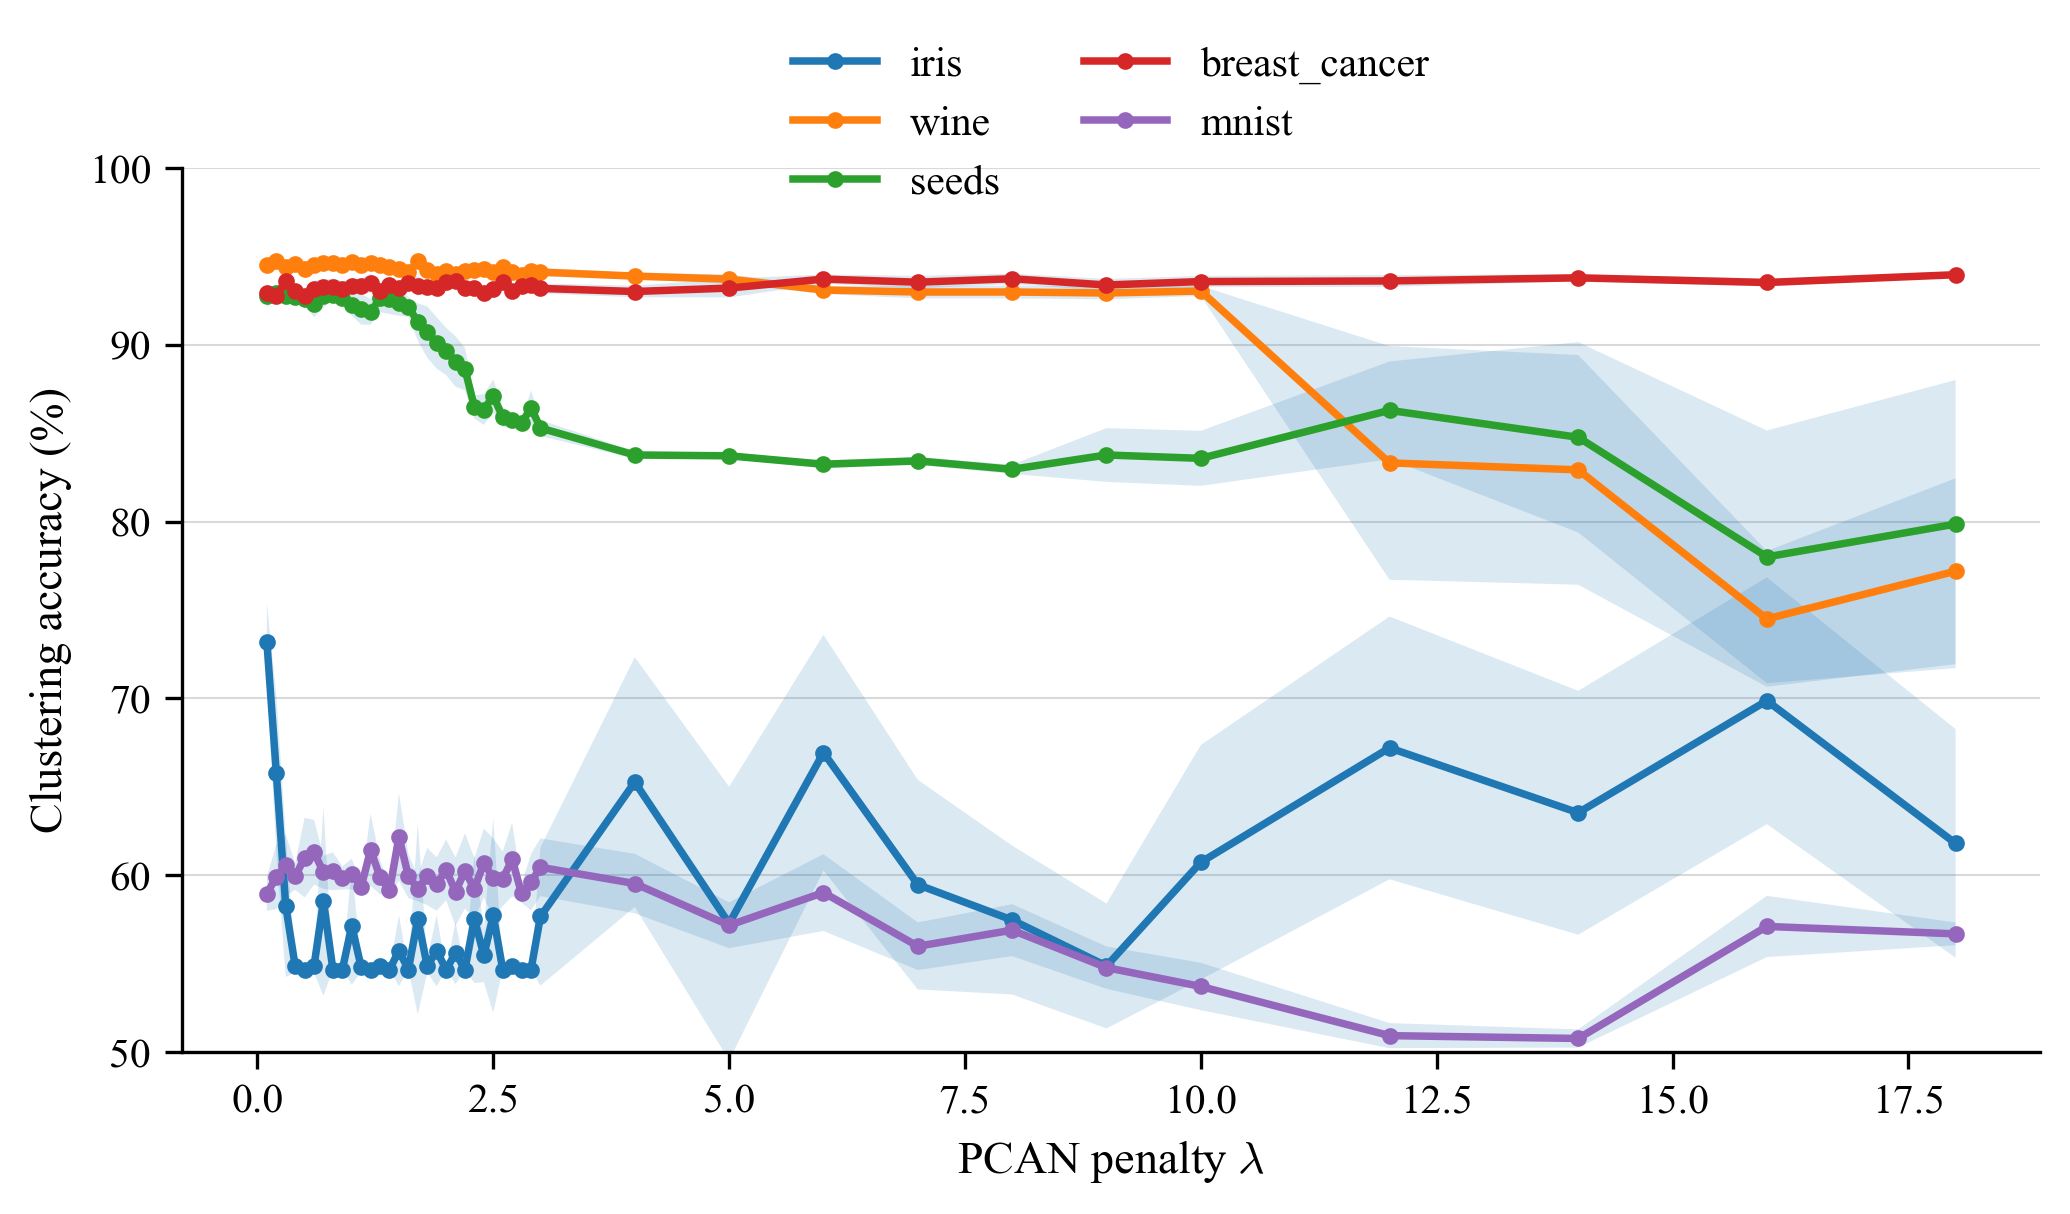

In [54]:
line_comparison(pcan_lambda, x='lambda', series='dataset', xlabel=r'PCAN penalty $\lambda$', markersize=3, filename='graph_construction/lambda_sensitivity', ylim=(50,100))

In [81]:
knn_acc = pd.read_csv('accuracies/graph_constructions/knn_accuracies.csv')

tcrit = stats.t.ppf(0.975, df=99)
knn_acc['sem'] = knn_acc['std'] / np.sqrt(10)
knn_acc['ci'] = tcrit * knn_acc['sem']
knn_acc['lower'] = knn_acc['mean'] - knn_acc['ci']
knn_acc['upper'] = knn_acc['mean'] + knn_acc['ci']
knn_acc

,dataset,k,mean,std,sem,ci,lower,upper
0,iris,5,55.000000,3.333333e+00,1.054093e+00,2.091548e+00,52.908452,57.091548
1,wine,5,94.612360,2.777028e-01,8.781735e-02,1.742487e-01,94.438111,94.786608
2,seeds,5,93.038095,2.323008e-01,7.345997e-02,1.457605e-01,92.892335,93.183856
3,breast_cancer,5,93.718805,2.615351e-01,8.270467e-02,1.641040e-01,93.554701,93.882909
4,mnist,5,60.933000,3.151392e+00,9.965578e-01,1.977387e+00,58.955613,62.910387
5,iris,10,55.000000,3.333333e+00,1.054093e+00,2.091548e+00,52.908452,57.091548
6,wine,10,94.623596,2.795336e-01,8.839629e-02,1.753974e-01,94.448198,94.798993
7,seeds,10,93.076190,2.385277e-01,7.542910e-02,1.496677e-01,92.926523,93.225858
8,breast_cancer,10,93.808436,2.570046e-01,8.127198e-02,1.612612e-01,93.647175,93.969697
9,mnist,10,60.885500,3.105317e+00,9.819875e-01,1.948476e+00,58.937024,62.833976


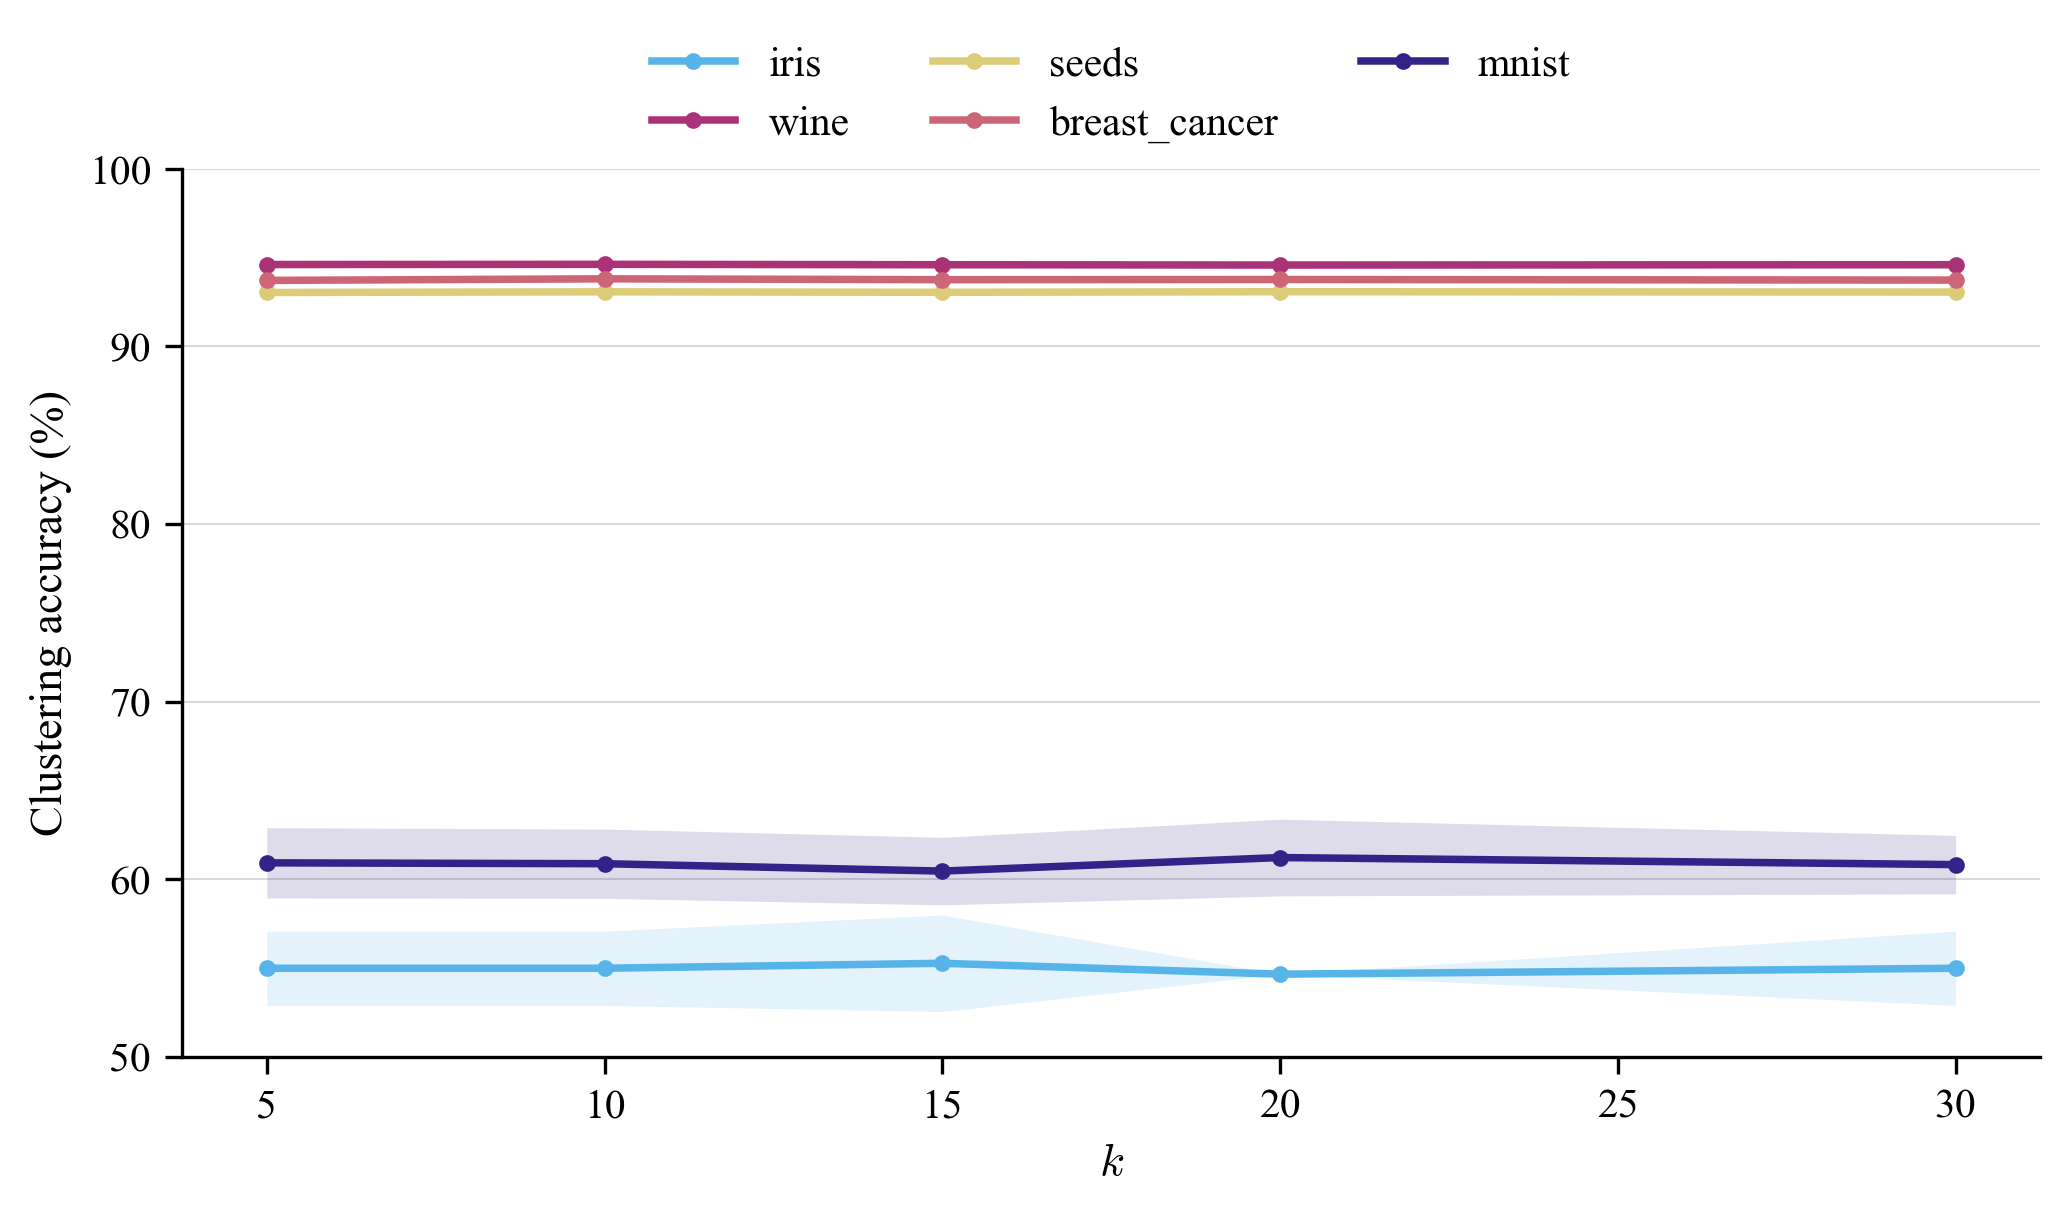

In [91]:
line_comparison(knn_acc, x='k', series='dataset', xlabel=r'$k$', markersize=3, filename='graph_construction/knn_sensitivity', ylim=(50,100))

In [ ]:
biclique_acc = pd.read_csv('accuracies/graph_constructions/biclique_accuracies.csv')

tcrit = stats.t.ppf(0.975, df=99)
biclique_acc['sem'] = biclique_acc['std'] / np.sqrt(10)
biclique_acc['ci'] = tcrit * biclique_acc['sem']
biclique_acc['lower'] = biclique_acc['mean'] - biclique_acc['ci']
biclique_acc['upper'] = biclique_acc['mean'] + biclique_acc['ci']
biclique_acc

,dataset,r,mean,std,sem,ci,lower,upper
0,iris,2,83.560000,3.173968e-01,1.003697e-01,1.991552e-01,83.360845,83.759155
1,wine,2,98.056180,2.814091e-01,8.898938e-02,1.765742e-01,97.879606,98.232754
2,seeds,2,90.476190,1.428245e-14,4.516506e-15,8.961728e-15,90.476190,90.476190
3,breast_cancer,2,63.093146,7.141223e-15,2.258253e-15,4.480864e-15,63.093146,63.093146
4,mnist,2,54.878000,3.437834e+00,1.087139e+00,2.157119e+00,52.720881,57.035119
5,iris,4,84.666667,2.856489e-14,9.033012e-15,1.792346e-14,84.666667,84.666667
6,wine,4,97.752809,1.428245e-14,4.516506e-15,8.961728e-15,97.752809,97.752809
7,seeds,4,92.676190,2.323008e-01,7.345997e-02,1.457605e-01,92.530430,92.821951
8,breast_cancer,4,90.428822,8.803309e-02,2.783851e-02,5.523764e-02,90.373585,90.484060
9,mnist,4,54.695000,3.092362e+00,9.778907e-01,1.940347e+00,52.754653,56.635347


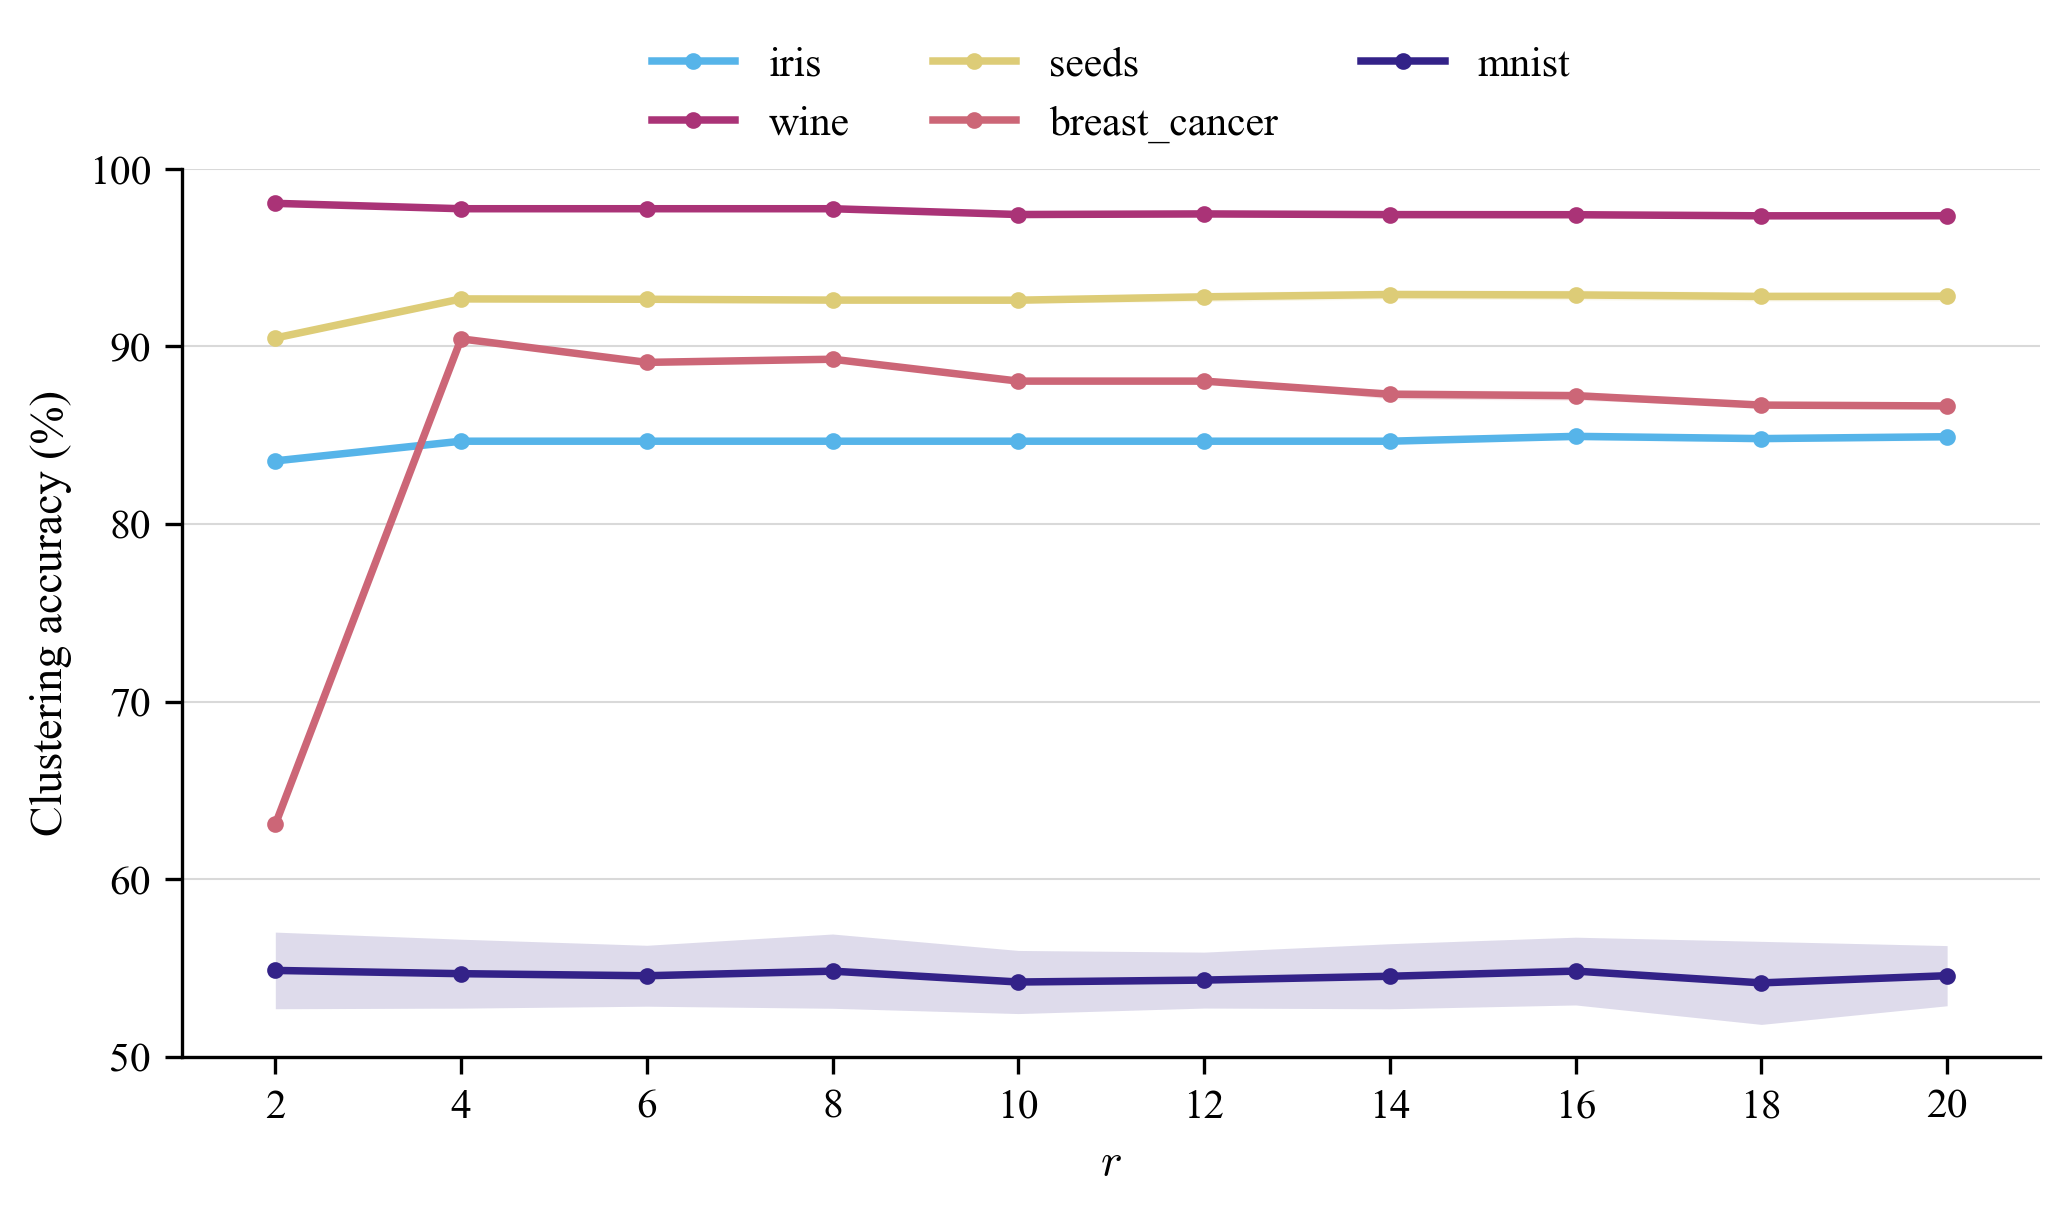

In [113]:
line_comparison(biclique_acc, x='r', series='dataset', xlabel=r'$r$', markersize=3, filename='graph_construction/biclique_sensitivity', ylim=(50,100), xlim=(1,21))

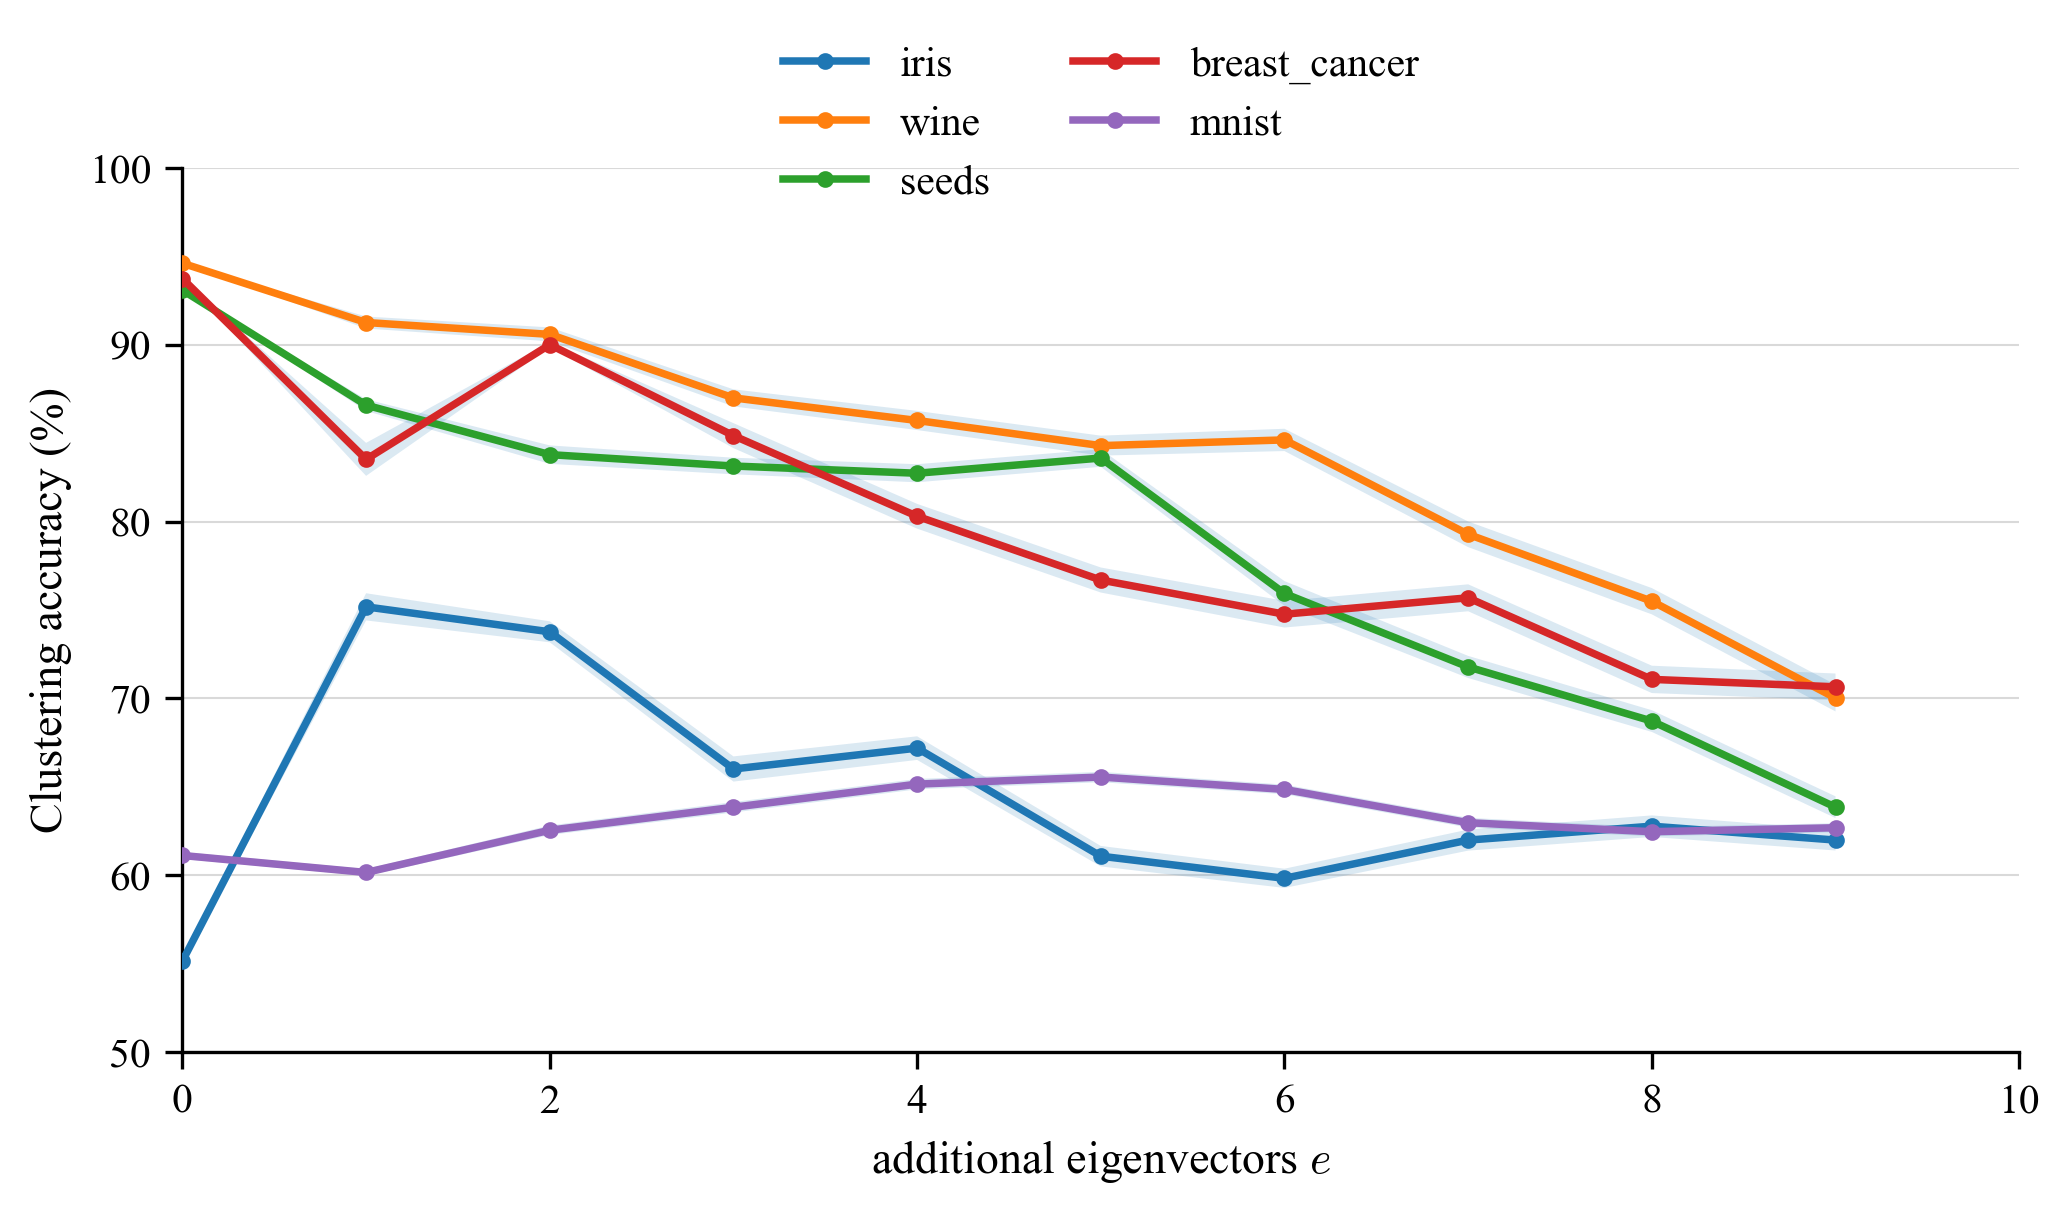

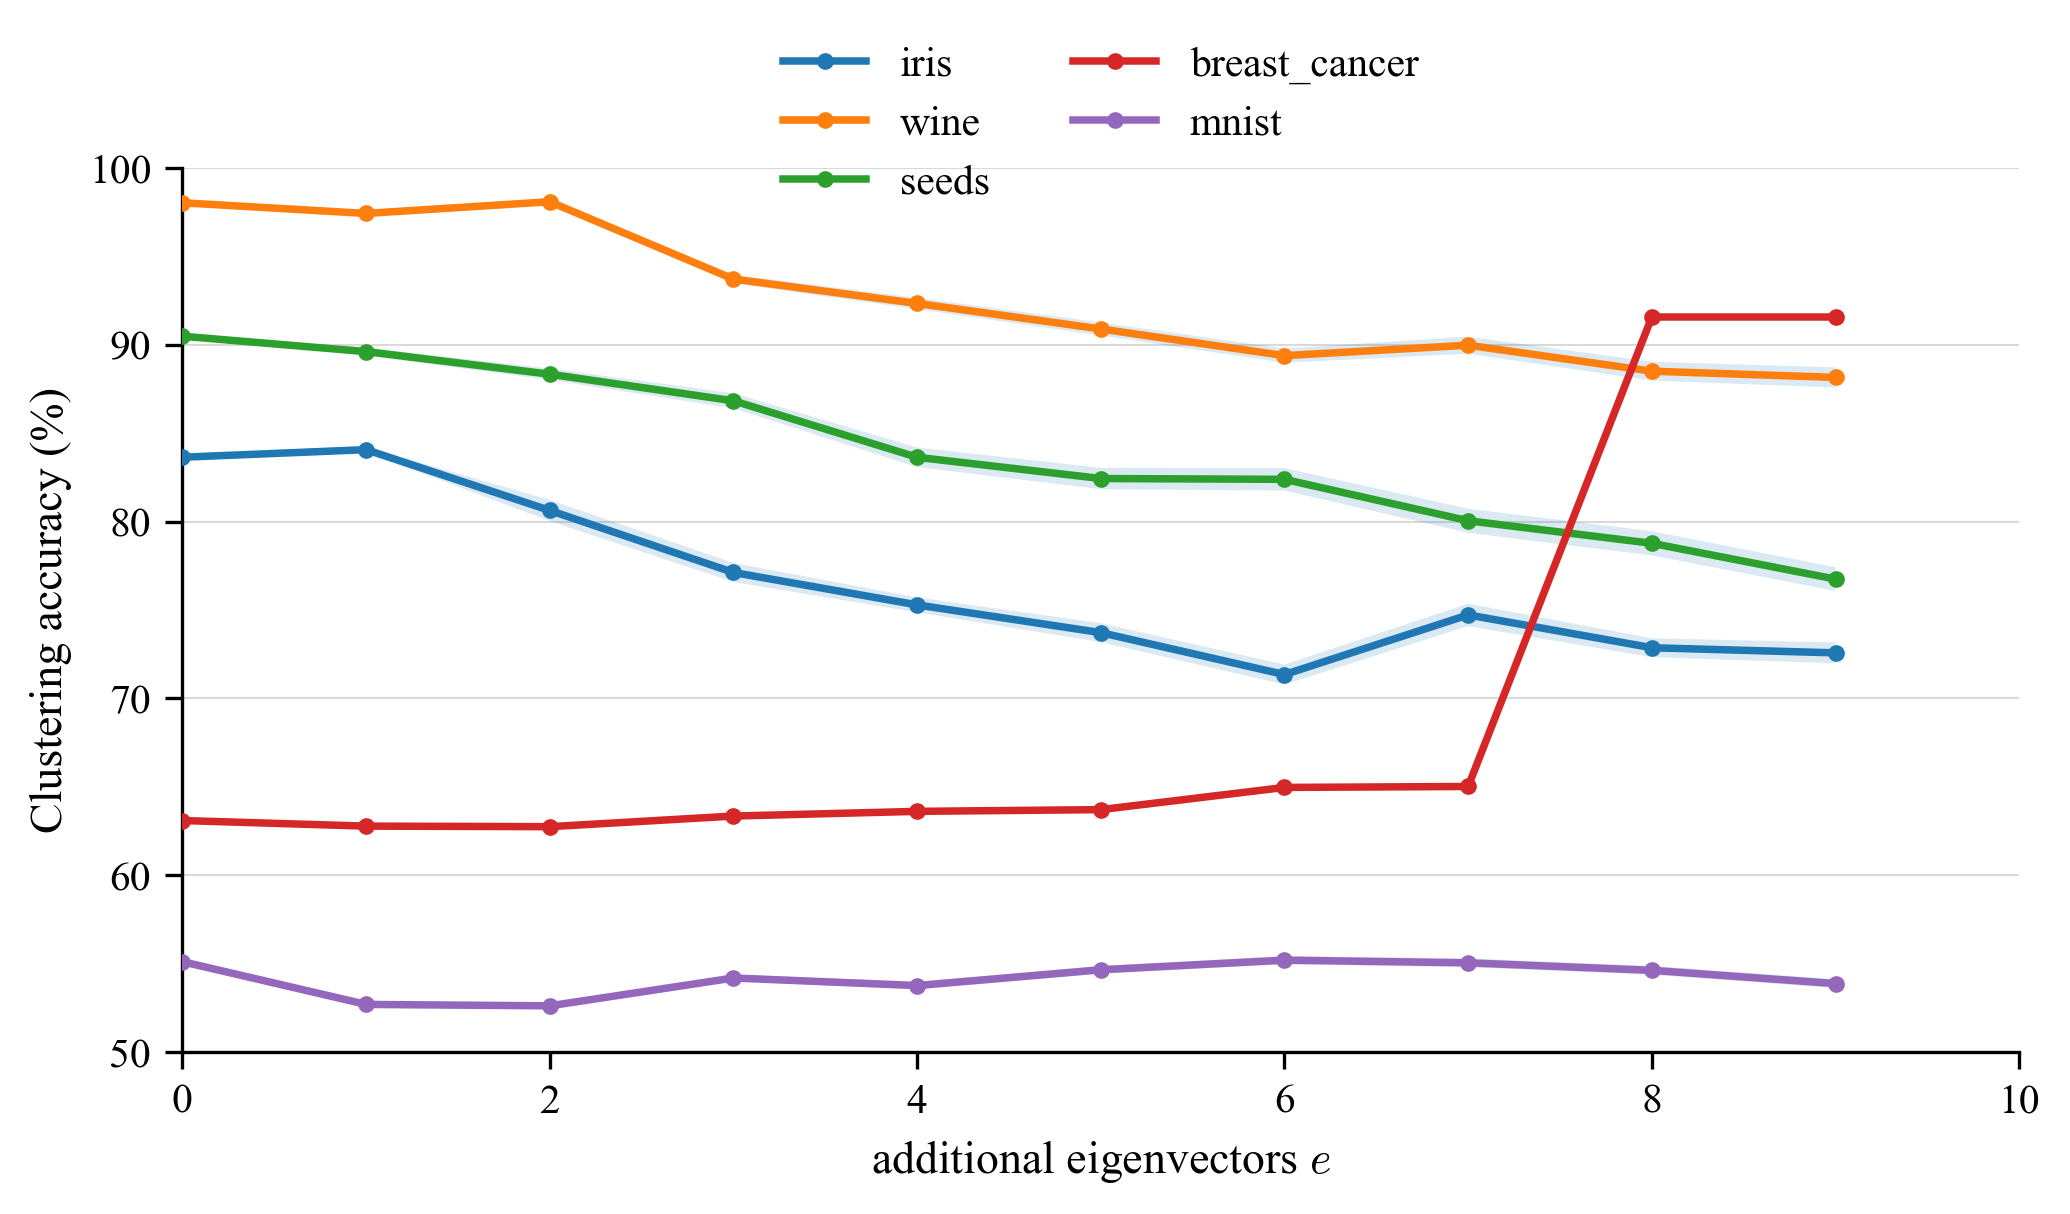

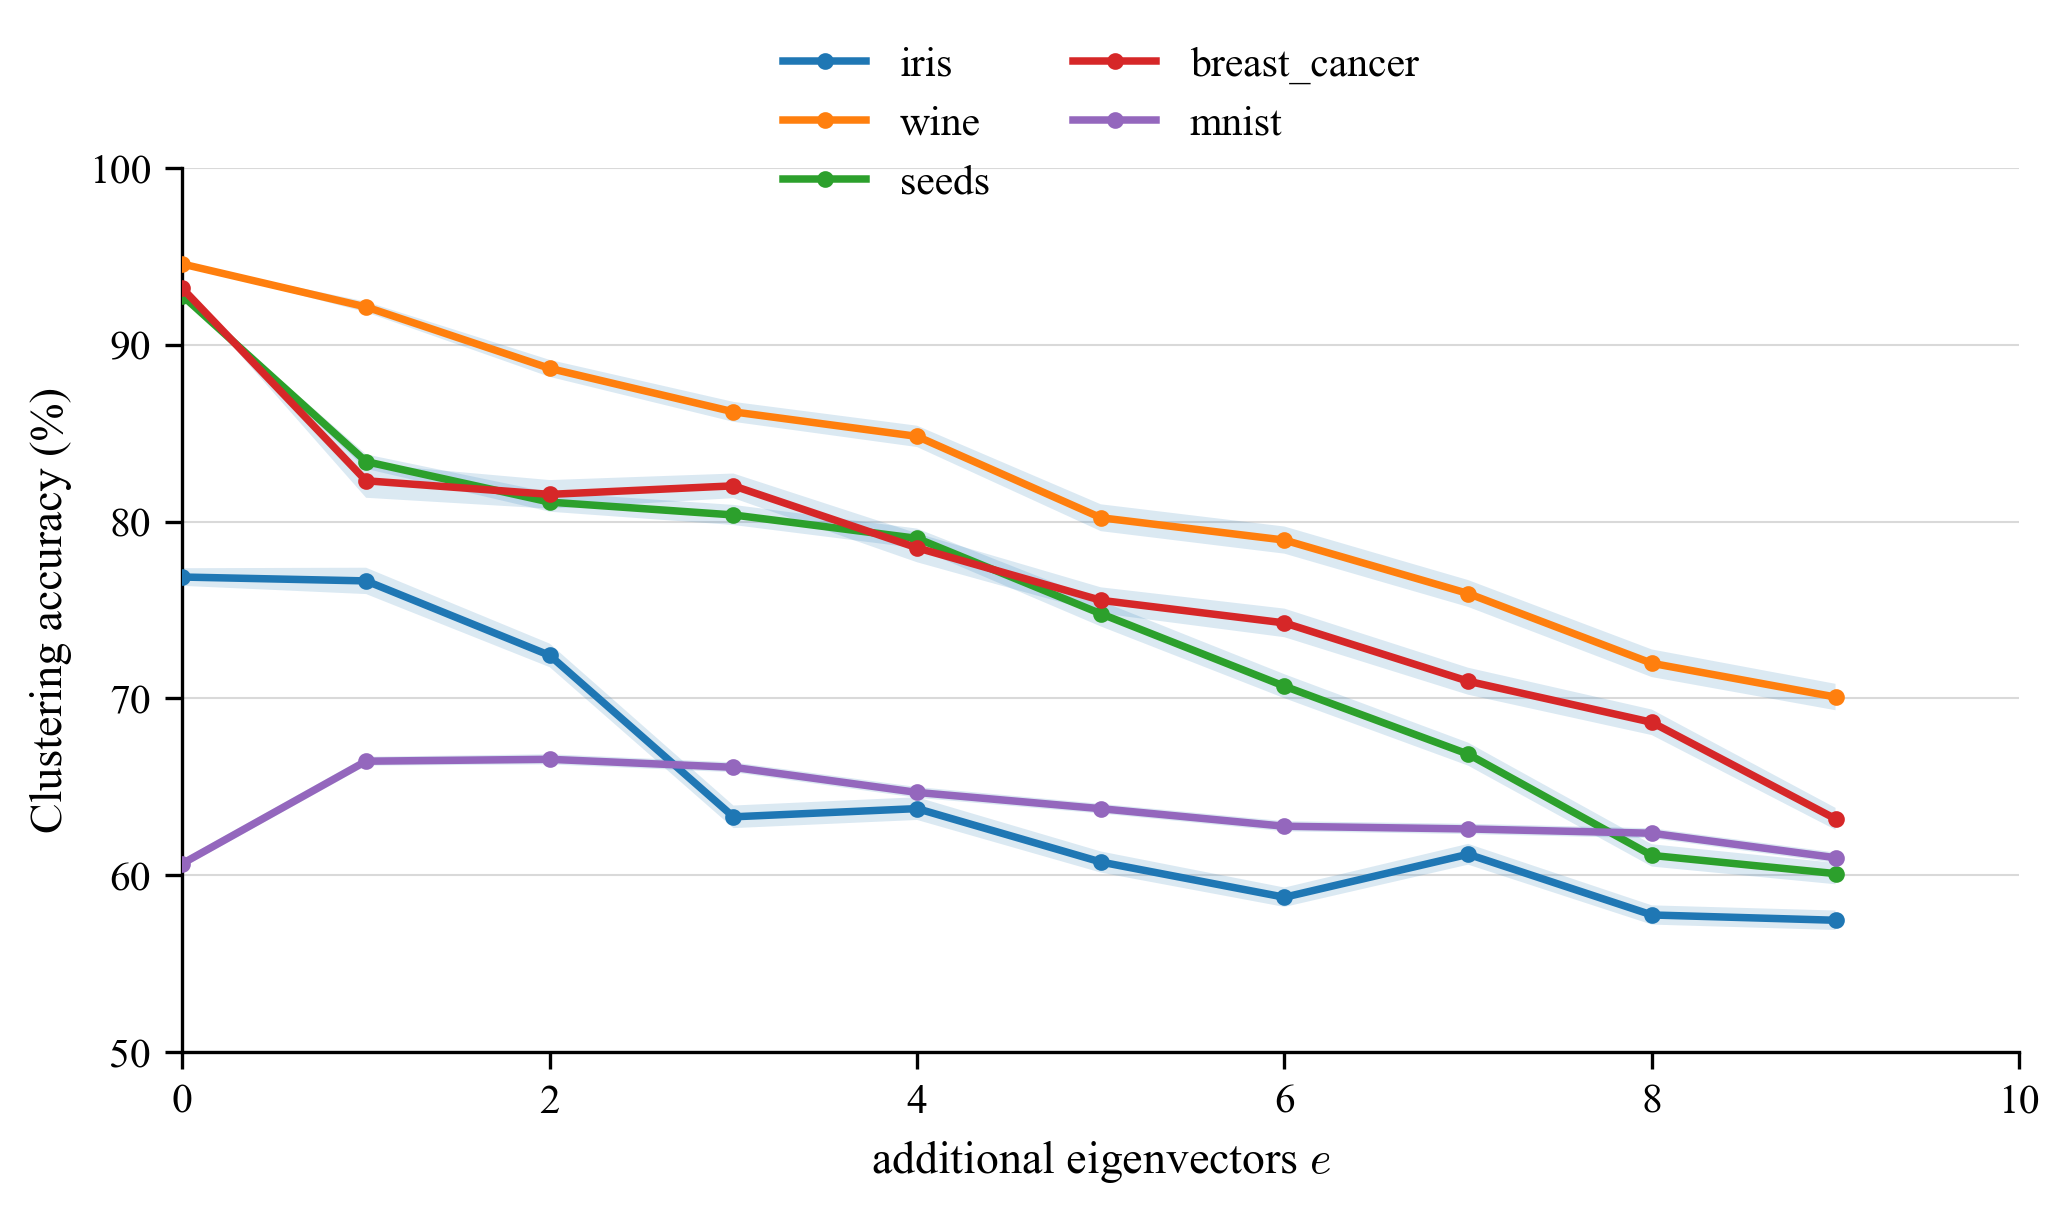

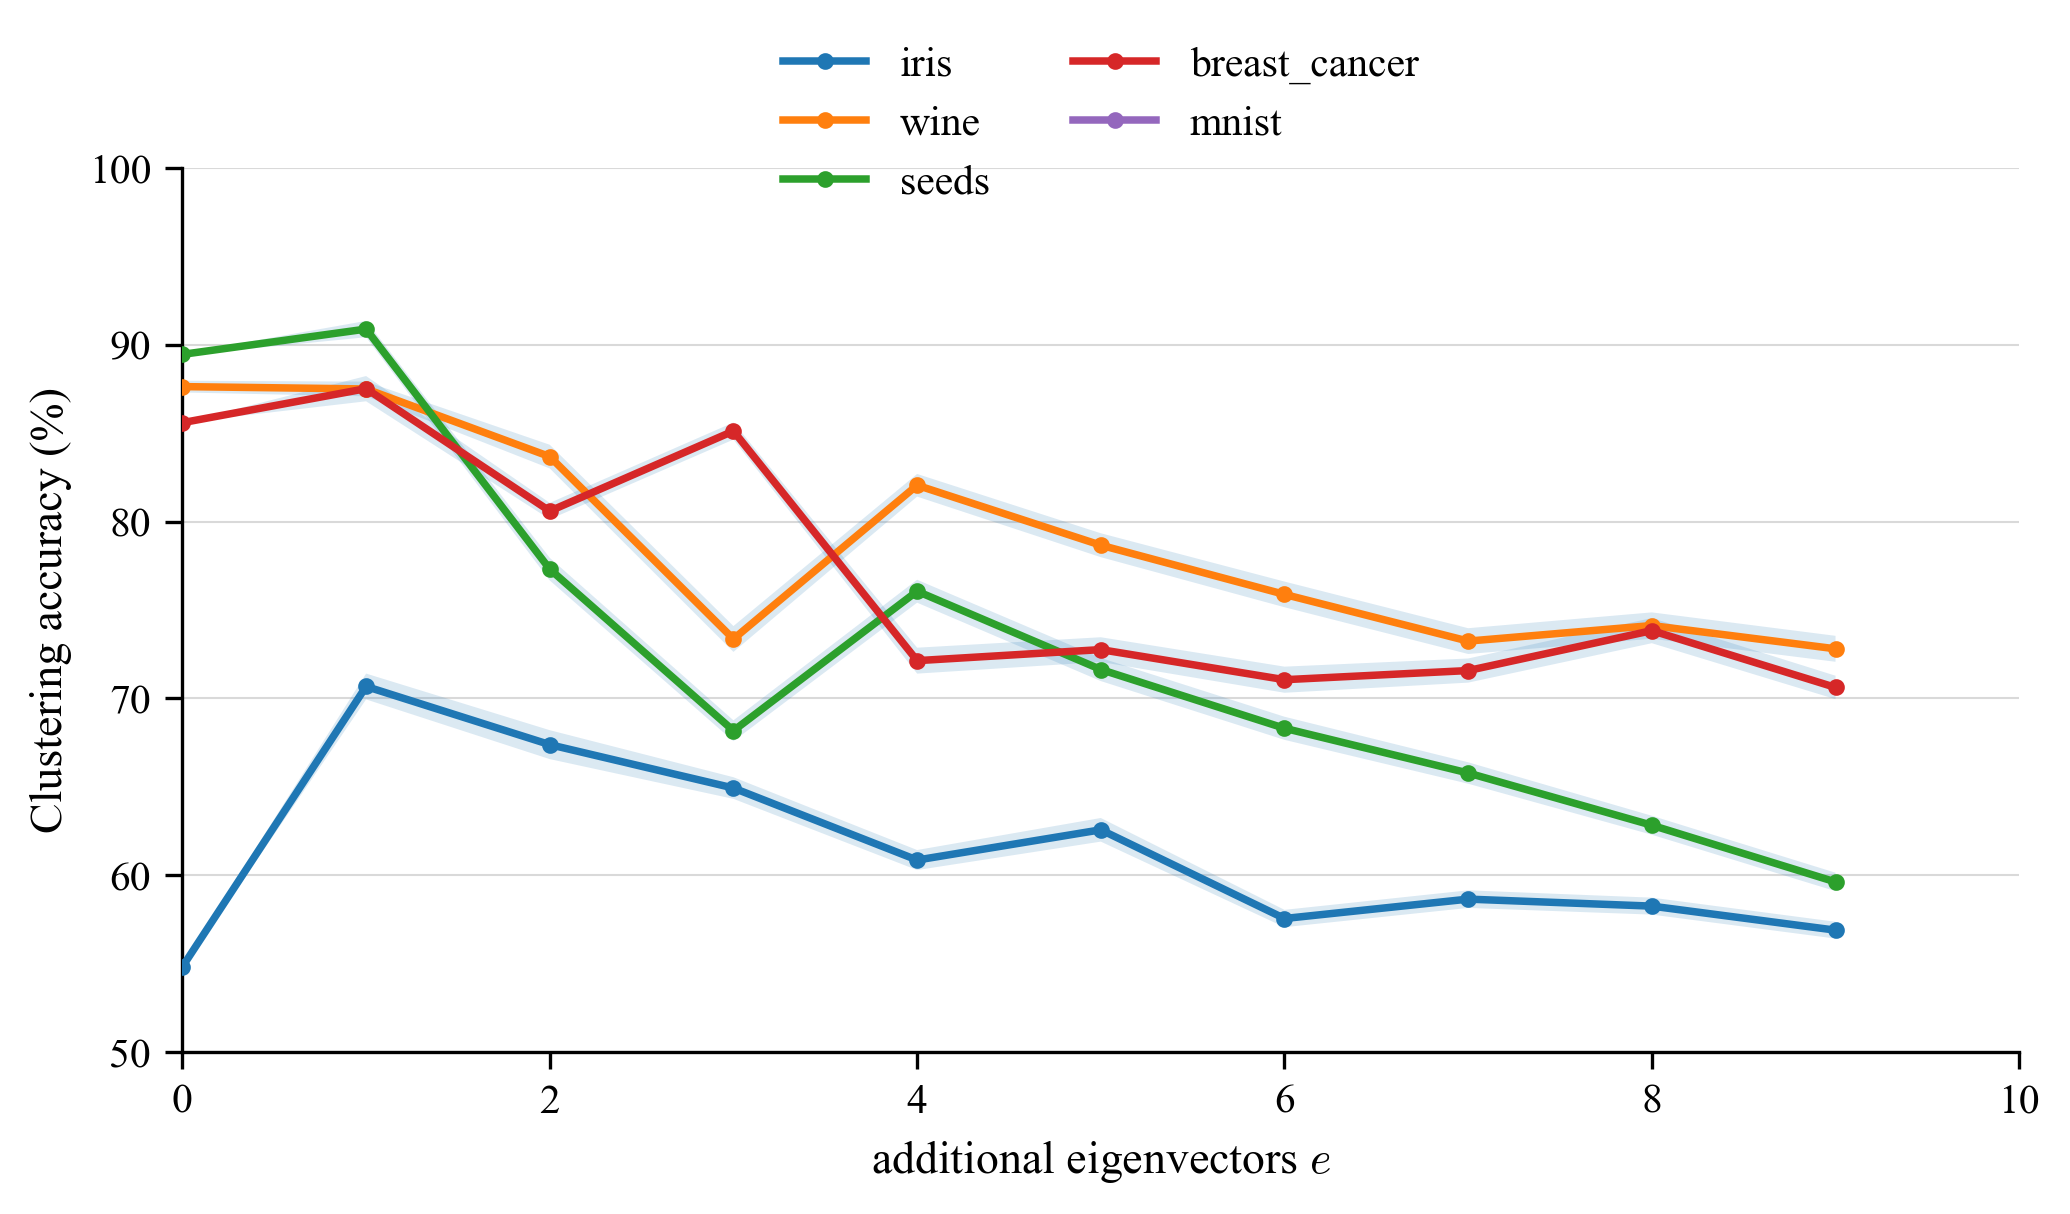

In [55]:
parent = pd.read_csv('accuracies/graph_constructions/accuracy_eigs.csv')
methods = ['knn', 'fc', 'adaptive', 'biclique']
tcrit = stats.t.ppf(0.975, df=99)
for method in methods:
    temp = parent.filter(['dataset', 'extra_eigs', f'{method}_mean', f'{method}_std'])
    temp = temp.rename(columns={f'{method}_mean': 'mean', f'{method}_std': 'std'})
    temp['sem'] = temp['std'] / np.sqrt(1000)
    temp['ci'] = tcrit * temp['sem']
    temp['lower'] = temp['mean'] - temp['ci']
    temp['upper'] = temp['mean'] + temp['ci']
    line_comparison(temp, x='extra_eigs', series='dataset', xlabel=r'additional eigenvectors $e$', markersize=3, filename=f'graph_construction/{method}_extra_eigs', ylim=(50,100), xlim=(0,10))